<a href="https://colab.research.google.com/github/AmirAsgary/Teaching/blob/main/MachineLearning_MolBio_2025/Tutorial/Tutorial_3_Answerkey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality reduction and logistic regression


In this tutorial we will implement dimensionality reduction with PCA followed by logistic regression.

You will be plotting relevant results for visualization and understanding, as you go through the objectives.

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(context='talk',style='white',palette='colorblind')
import pickle
import matplotlib
import scipy as sp
from scipy.sparse import csc_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import Bunch
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from collections import Counter
%matplotlib inline
import random
random.seed(42)

## Task 0: Load and normalize count data

This practical uses the data set from https://www.nature.com/articles/s41586-018-0654-5. This is single cell transcriptomics data from ~25,000 cells from the cortex.

For each of these cells, the expression of several thousand genes was measured ```['counts']```. In the original study, the authors were interested in clustering the cells into types.

We made a selection of 5000 cells and the 1000 most informative genes for run time reasons. We provide you with the original cell type labels determined by the authors for comparison ```['clusters']```.

The following function will apply some preprocessing steps that are standard for transcriptomics data. We normalize the data to bring columns to comparable sizes and log-transform them as they contain huge outliers.

In [101]:
def lognormalize_counts(tasic_dict):
    # normalize and log-transform counts
    counts = tasic_dict['counts']
    libsizes = counts.sum(axis=1)
    CPM = counts / libsizes * 1e+6
    # Apply log transformation while keeping sparse structure
    CPM_copy = CPM.copy()
    CPM_copy.data = np.log2(CPM_copy.data + 1)  # Only transform non-zero values
    # Standardize
    tasic_dict['logCPM'] = CPM_copy
    return tasic_dict

In [102]:
tasic_1k = lognormalize_counts(pickle.load(open('/content/tasic_subset_1kselected.pickle', 'rb')))

/tmp/ipython-input-3394590446.py:1: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  tasic_1k = lognormalize_counts(pickle.load(open('/content/tasic_subset_1kselected.pickle', 'rb')))


Have a look at ```['counts']```, ```['logCPM']``` and ```['clusters']``` to get a better understanding of the data. Plot a histogram of the cell type labels provided by  ```['clusters']```.

In [ ]:
# Explore data


In [103]:
# Explore data
# 1. Look at the counts data
print("Counts shape:", tasic_1k['counts'].shape)
print("Counts type:", type(tasic_1k['counts']))
print("First few rows and columns of counts:")
print(tasic_1k['counts'][:5, :5].toarray())

# 2. Look at the logCPM data
print("\nlogCPM shape:", tasic_1k['logCPM'].shape)
print("logCPM type:", type(tasic_1k['logCPM']))
print("First few rows and columns of logCPM:")
# Convert coo_matrix to array for viewing
print(tasic_1k['logCPM'].toarray()[:5, :5])

# 3. Look at the clusters (cell type labels)
print("\nClusters shape:", tasic_1k['clusters'].shape)
print("Clusters type:", type(tasic_1k['clusters']))
print("Unique cell types:", np.unique(tasic_1k['clusters']))
print("First 10 cluster labels:", tasic_1k['clusters'][:10])

Counts shape: (5000, 1000)
Counts type: <class 'scipy.sparse._csc.csc_matrix'>
First few rows and columns of counts:
[[  0.   0.   0.   0. 650.]
 [  0.   0.   0.   0. 176.]
 [  0.   0.   0.   0.   3.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]]

logCPM shape: (5000, 1000)
logCPM type: <class 'scipy.sparse._coo.coo_matrix'>
First few rows and columns of logCPM:
[[ 0.          0.          0.          0.         11.45153902]
 [ 0.          0.          0.          0.         10.58324059]
 [ 0.          0.          0.          0.          4.28924964]
 [ 0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.        ]]

Clusters shape: (5000,)
Clusters type: <class 'numpy.ndarray'>
Unique cell types: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  

In [104]:
# Plotting --> bar plot of number of samples


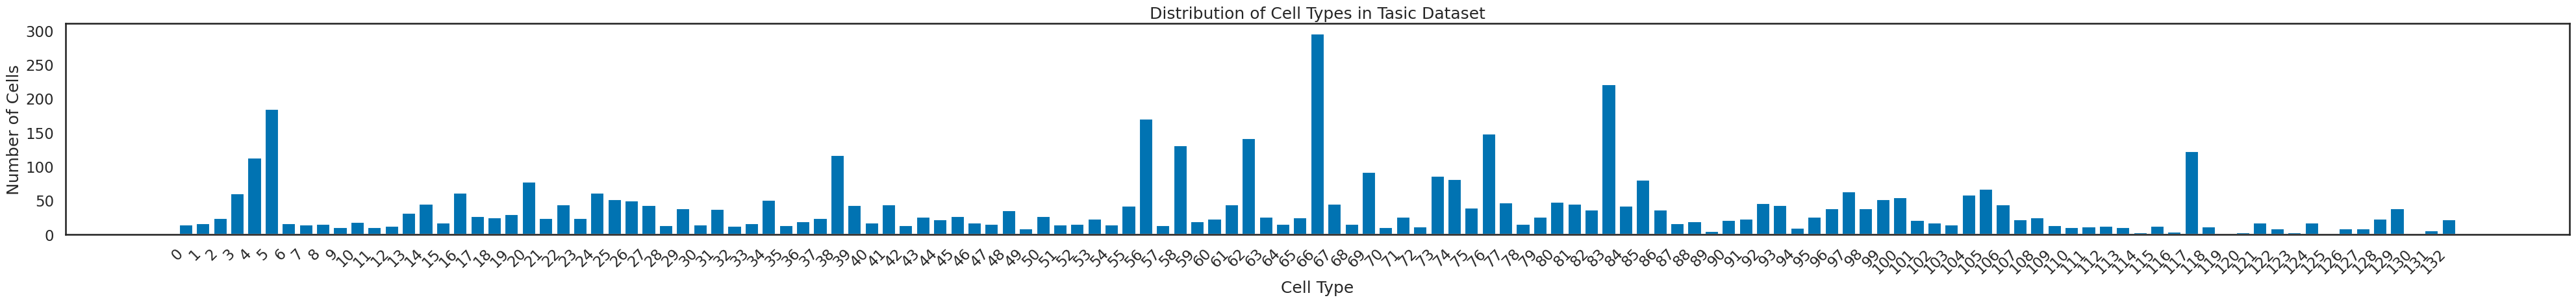

In [105]:
# Plotting
# 4. Plot histogram of cell type labels
plt.figure(figsize=(40, 5))
unique_clusters, counts = np.unique(tasic_1k['clusters'], return_counts=True)
plt.bar(range(len(unique_clusters)), counts)
plt.xticks(range(len(unique_clusters)), unique_clusters, rotation=45, ha='right')
plt.xlabel('Cell Type')
plt.ylabel('Number of Cells')
plt.title('Distribution of Cell Types in Tasic Dataset')
plt.tight_layout()
plt.show()


# Principal Component Analysis (PCA)

## What is PCA?

**Principal Component Analysis (PCA)** is a dimensionality reduction technique that helps us simplify complex, high-dimensional data while preserving the most important patterns. Think of it as finding the "best angles" to view your data.

---

## How Does PCA Work?

### Step 1: Center the Data
First, we subtract the mean expression of each gene across all cells. This centers the data around zero.

### Step 2: Find Directions of Maximum Variance
PCA searches for new axes (called **principal components**) that capture the most variation in the data:

- **PC1** (Principal Component 1): The direction where data varies the MOST
- **PC2**: The direction with the second most variation (perpendicular to PC1)
- **PC3**: The third most variation (perpendicular to both PC1 and PC2)
- And so on...

### Step 3: Project Data onto New Axes
We transform our original gene expression data onto these new PC axes. Each cell now has "PC scores" instead of gene expression values.

---

## Mathematical Representation

Each principal component is a **weighted combination** of original genes:

$$\text{PC1} = w_1 \times \text{Gene}_1 + w_2 \times \text{Gene}_2 + ... + w_{1000} \times \text{Gene}_{1000}$$

Where $w_i$ are the **weights** (or loadings) that tell us how much each gene contributes to that PC.

### Example:
If PC1 has:
- High positive weights for **cell cycle genes** → high PC1 score = actively dividing
- High negative weights for **differentiation genes** → low PC1 score = differentiated

Then **PC1 captures the cell cycle vs. differentiation axis**!


## Task1: Fill the following function and continue the excercises

In [ ]:
def PCA_sklearn(data):
    '''
    Function that performs PCA on the input data, using sklearn

    input: (cells, genes)-shaped array of log transformed cell counts
    output:
        fraction_variance_explained: (genes,)-shaped array with the fraction of variance explained by the individual PCs
        principal_components: (genes, genes)-shaped array containing the principal components as columns
        transformed_data: (cells, genes)-shaped array containing the transformed data (PC scores for each cell)
    '''

    # ---------------- INSERT CODE ----------------------



    # ---------------- END CODE -------------------------

    return fraction_variance_explained, principal_components, transformed_data

In [106]:
def PCA_sklearn(data):
    '''
    Function that performs PCA on the input data, using sklearn

    input: (cells, genes)-shaped array of log transformed cell counts
    output:
        fraction_variance_explained: (genes,)-shaped array with the fraction of variance explained by the individual PCs
        principal_components: (genes, genes)-shaped array containing the principal components as columns
        transformed_data: (cells, genes)-shaped array containing the transformed data (PC scores for each cell)
    '''

    # ---------------- INSERT CODE ----------------------

    from sklearn.decomposition import PCA

    # Step 1: Convert sparse matrix to dense array if necessary
    # Sparse matrices are memory-efficient but PCA needs dense arrays
    if hasattr(data, 'toarray'):
        data = data.toarray()

    # Step 2: Initialize PCA with all possible components
    # n_components = min(n_samples, n_features) = min(5000 cells, 1000 genes) = 1000
    # We request all components to see the full variance breakdown
    pca = PCA(n_components=data.shape[1])

    # Step 3: Fit PCA on the data
    # This computes the principal components by finding the directions of maximum variance
    # Internally, sklearn centers the data (subtracts mean) and computes eigenvectors
    pca.fit(data)

    # Step 4: Get the fraction of variance explained by each PC
    # This tells us how important each PC is (values sum to 1.0)
    # Example: [0.35, 0.15, 0.10, ...] means PC1 explains 35%, PC2 explains 15%, etc.
    fraction_variance_explained = pca.explained_variance_ratio_

    # Step 5: Get the principal components (the transformation matrix)
    # pca.components_ has shape (n_components, n_features) = (1000 PCs, 1000 genes)
    # Each row is one PC, showing how each gene contributes to that PC
    # We transpose to get (genes, PCs) format with PCs as columns
    # Result shape: (1000 genes, 1000 PCs)
    principal_components = pca.components_.T

    # Step 6: Transform the original data into PC space
    # This projects each cell onto the new PC axes
    # Result: PC scores for each cell showing where they lie in the new coordinate system
    # Shape: (5000 cells, 1000 PCs)
    # Each row represents one cell's coordinates in PC space
    transformed_data = pca.transform(data)

    # ---------------- END CODE -------------------------

    return fraction_variance_explained, principal_components, transformed_data

In [107]:
# Run after writing the function - Do not change -
# do sklearn-PCA on selected genes
fraction_variance_explained, principal_components, transformed_data = PCA_sklearn(tasic_1k['logCPM'])

In [ ]:
# ==========================================
# EXERCISE 1: How much variance do the first 2 PCs capture?
# ==========================================
# hint: use np.sum()

# =============== Insert your code here ===============

# =============== Finish your code here and do not change below ===============
print(f"PC1 and PC2 together explain {cumulative_variance_pc1_pc2:.2%} of the total variance")

In [108]:
# ==========================================
# EXERCISE 1: How much variance do the first 2 PCs capture?
# ==========================================
# hint: use np.sum()

# =============== Insert your code here ===============
cumulative_variance_pc1_pc2 = np.sum(fraction_variance_explained[:2])

# =============== Finish your code here and do not change below ===============
print(f"PC1 and PC2 together explain {cumulative_variance_pc1_pc2:.2%} of the total variance")

PC1 and PC2 together explain 37.30% of the total variance


In [ ]:
# ==========================================
# EXERCISE 2: How many PCs do we need to capture 80% of variance?
# ==========================================
# hint: use np.cumsum and np.argmax

# =============== Insert your code here ===============


# =============== Finish your code here and do not change below ===============
print(f"We need {n_pcs_for_80_percent} PCs to capture at least 80% of variance")
print(f"These {n_pcs_for_80_percent} PCs explain {cumulative_variance[n_pcs_for_80_percent-1]:.2%} of variance")

In [109]:
# ==========================================
# EXERCISE 2: How many PCs do we need to capture 80% of variance?
# ==========================================
# hint: use np.cumsum and np.argmax

# =============== Insert your code here ===============
cumulative_variance = np.cumsum(fraction_variance_explained)
n_pcs_for_80_percent = np.argmax(cumulative_variance >= 0.80) + 1  # +1 because index starts at 0

# =============== Finish your code here and do not change below ===============
print(f"We need {n_pcs_for_80_percent} PCs to capture at least 80% of variance")
print(f"These {n_pcs_for_80_percent} PCs explain {cumulative_variance[n_pcs_for_80_percent-1]:.2%} of variance")

We need 74 PCs to capture at least 80% of variance
These 74 PCs explain 80.04% of variance


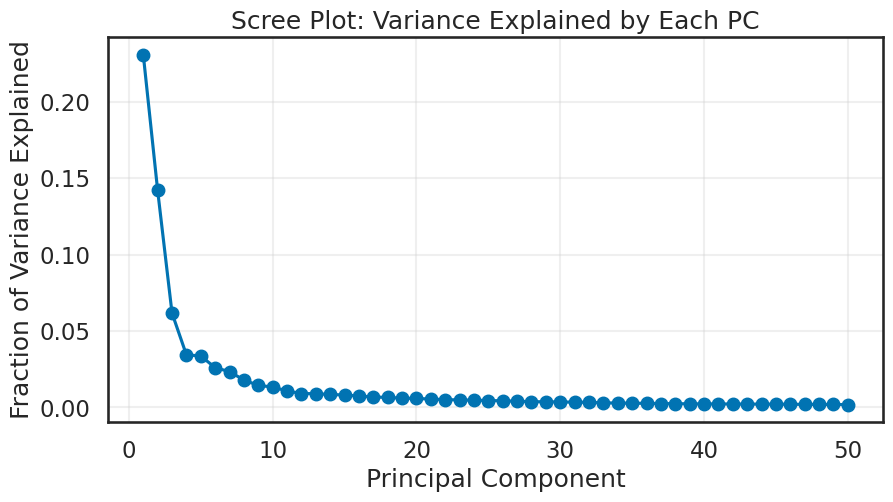

In [110]:
# Plot the variance explained by each PC
plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), fraction_variance_explained[:50], 'bo-')  # Plot first 50 PCs
plt.xlabel('Principal Component')
plt.ylabel('Fraction of Variance Explained')
plt.title('Scree Plot: Variance Explained by Each PC')
plt.grid(True, alpha=0.3)
plt.show()

**Question:** What do you observe?
After how many principal components your plot gets platue?
Does that mean that you can simplify your 1000 dimensional data into a much lower dimension?

## Visualize daata after dimension reduction
Let's visualize the clusters of cells now only using the first and second principal components as a scatter plot.
To make your life easier, we wrote the visualization function below and you can just run it.

/tmp/ipython-input-3070339158.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


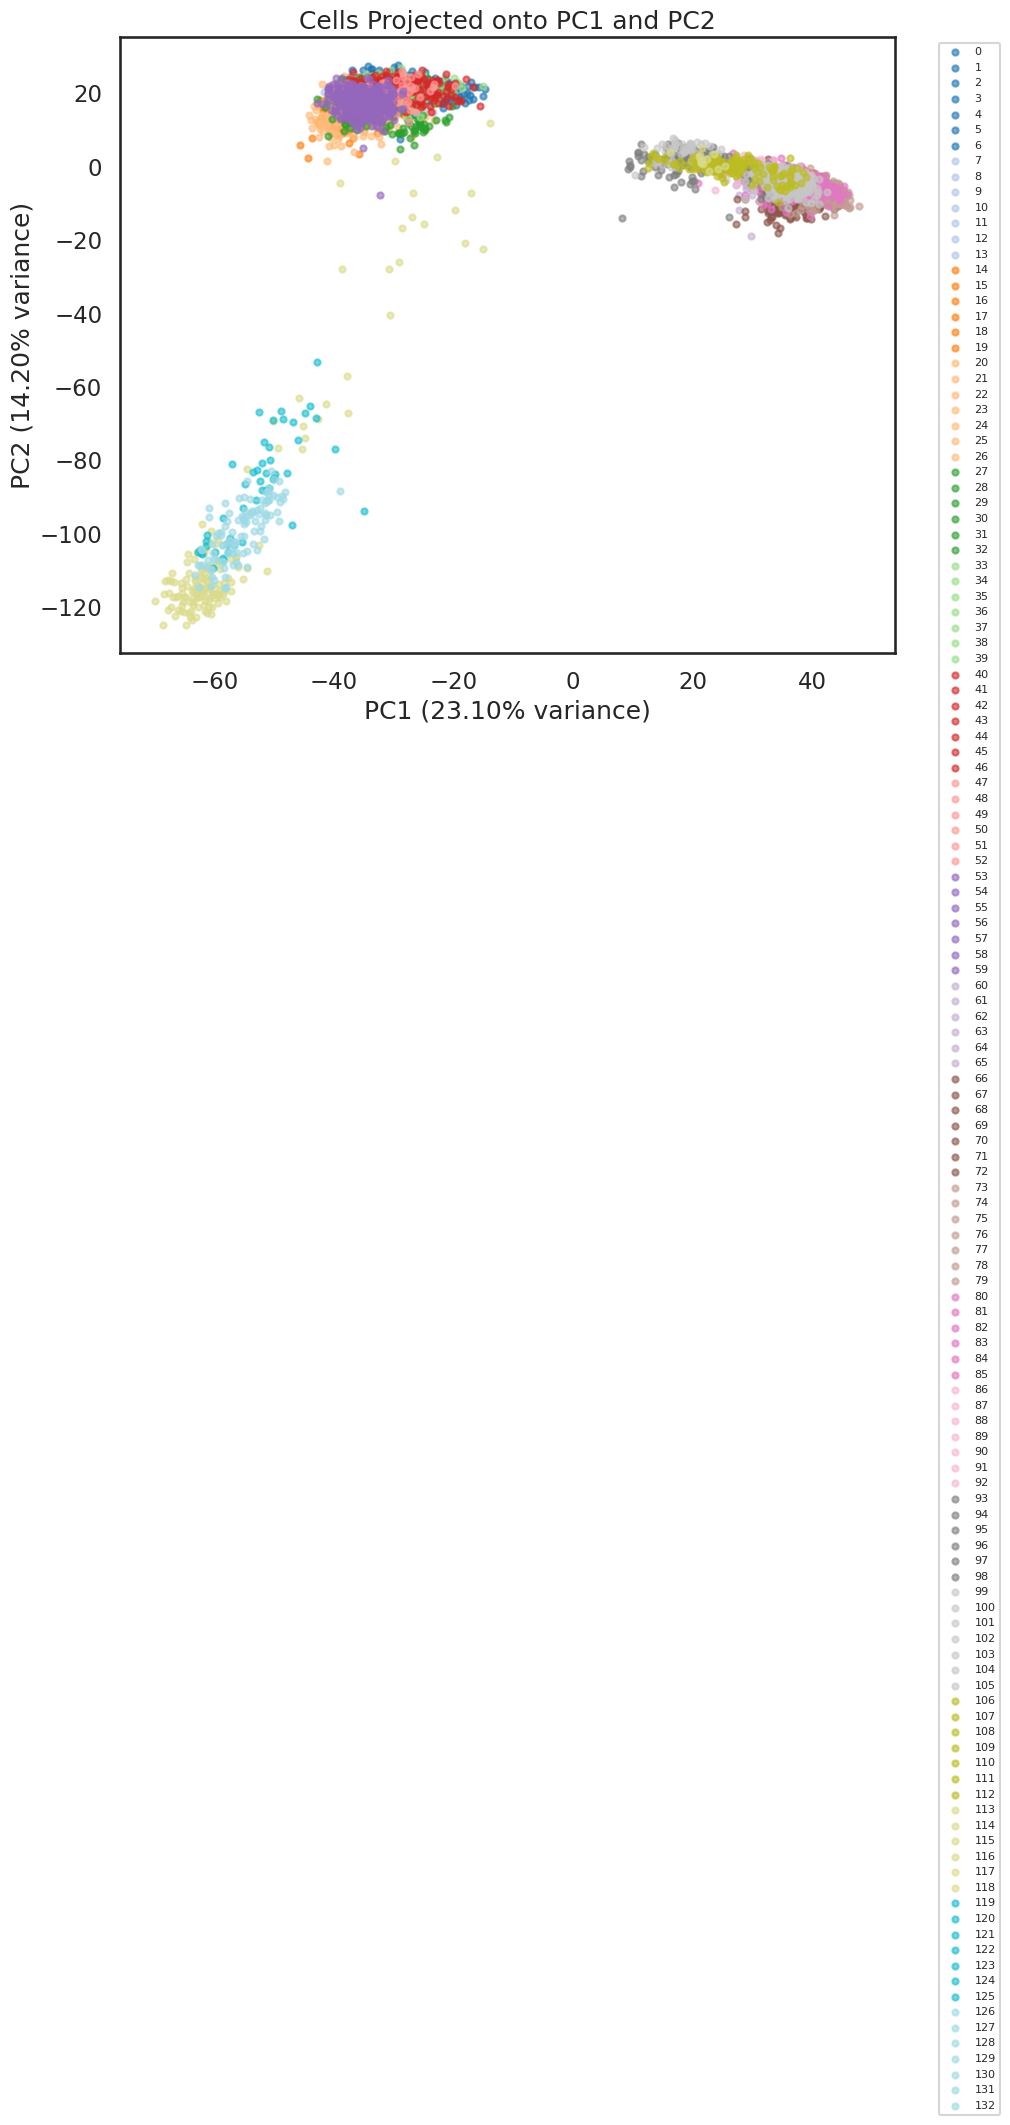

In [111]:
# Create a scatter plot of cells using their PC1 and PC2 scores, colored by cell type
plt.figure(figsize=(10, 8))
unique_clusters = np.unique(tasic_1k['clusters'])
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))


for i, cluster in enumerate(unique_clusters):
    mask = tasic_1k['clusters'] == cluster
    plt.scatter(transformed_data[mask, 0],  # PC1 scores
                transformed_data[mask, 1],  # PC2 scores
                c=[colors[i]],
                label=cluster,
                alpha=0.6,
                s=20)

plt.xlabel(f'PC1 ({fraction_variance_explained[0]:.2%} variance)')
plt.ylabel(f'PC2 ({fraction_variance_explained[1]:.2%} variance)')
plt.title('Cells Projected onto PC1 and PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

-------------
-----------
----------
---------

# Logistic Regression

 Logistic Regression is a statistical method used for binary or multi-class classification tasks. Unlike linear regression, which predicts continuous outcomes, logistic regression predicts the probability that a given observation belongs to a particular class.

 The model uses the logistic (sigmoid) function to map any real-valued input to a range between 0 and 1. The general form of the model is:

$$
\hat{y_i} = \sigma\left(w_0 + w_1 x_{i1} + w_2 x_{i2} + \dots + w_n x_{in}\right) = \frac{1}{1 + e^{-\left(w_0 + w_1 x_{i1} + \dots + w_n x_{in}\right)}}
$$

 where $\hat{y_i}$ is the predicted probability that observation $i$ belongs to the positive class, $w_0$ is the intercept, $w_1, w_2, \dots, w_n$ are weights corresponding to each feature $x_1, x_2, \dots, x_n$, and $\sigma(\cdot)$ is the sigmoid function which ensures outputs lie between 0 and 1.

 The coefficients $w$ are estimated by minimizing the log-loss (cross-entropy loss):

$$
L(w) = - \sum_{i=1}^m \left[ y_i \log(\hat{y_i}) + (1 - y_i) \log(1 - \hat{y_i}) \right]
$$
 Where $m$ is the total number of samples in your data.

 In other words, logistic regression seeks the best set of weights $w$ that make the predicted probabilities $\hat{y_i}$ as close as possible to the actual class labels $y_i$.

---

# Multiclass Logistic Regression (Softmax Regression)

 When we have more than two classes, logistic regression is extended using the **softmax function**. Instead of a single sigmoid output, the model produces one score for each class, and the softmax function converts these scores into probabilities that sum to 1.

 For an input vector $\mathbf{x_i}$, the model computes:

$$
z_j = w_{j0} + w_{j1}x_{i1} + w_{j2}x_{i2} + \dots + w_{jn}x_{in}
$$

 for each class \( $j = 1, 2, \dots, K \$), where \( K \) is the total number of classes.

 The **softmax function** then converts these scores into probabilities:

$$
P(y_i = j \mid \mathbf{x_i}) = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}
$$

 This ensures that all predicted probabilities are positive and sum to one:

$$
\sum_{j=1}^{K} P(y_i = j \mid \mathbf{x_i}) = 1
$$

 The loss function for multiclass logistic regression is a generalization of binary cross-entropy, called **categorical cross-entropy**:

$$
L(w) = - \sum_{i=1}^m \sum_{j=1}^K y_{ij} \log P(y_i = j \mid \mathbf{x_i})
$$

 Where $m$ is the total number of samples and $K$ is the total number of classes. Here, $y_{ij} = 1$ if sample $i$ belongs to class $j$, otherwise $0$ .  

 In simple terms, **softmax regression** finds the set of weights that make the model’s predicted class probabilities match the true classes as closely as possible.


## Understanding the Confusion Matrix

A **confusion matrix** is a simple and powerful way to evaluate how well a classification model performs.  
It shows the number of correct and incorrect predictions made by the model, broken down by each class.

---

For a classification problem with multiple classes, the confusion matrix is a square table:

| **True \ Predicted** | **Class 1** | **Class 2** | **Class 3** | ... |
|----------------------:|:------------:|:------------:|:------------:|:--:|
| **Class 1** (Actual) |  ✅ Correct  | ❌ Wrong     | ❌ Wrong     | ... |
| **Class 2** (Actual) | ❌ Wrong     | ✅ Correct   | ❌ Wrong     | ... |
| **Class 3** (Actual) | ❌ Wrong     | ❌ Wrong     | ✅ Correct   | ... |
| ...                  | ...          | ...          | ...          | ... |

- Each **row** represents the **true class** (the actual label).
- Each **column** represents the **predicted class** (the label the model predicted).

---

### How to Interpret It

- **Diagonal elements (top-left → bottom-right):**  
  These show how many samples were correctly classified for each class.  
  The higher these numbers, the better the model performs.

- **Off-diagonal elements:**  
  These show where the model made mistakes — it predicted the wrong class.

---
### Key Metrics Derived from the Matrix

From the confusion matrix, we can calculate:
- **Accuracy** – overall correctness of predictions  
- **Precision** – how many predicted positives are actually correct  
- **Recall (Sensitivity)** – how many true positives the model successfully found  
- **F1-score** – balance between precision and recall



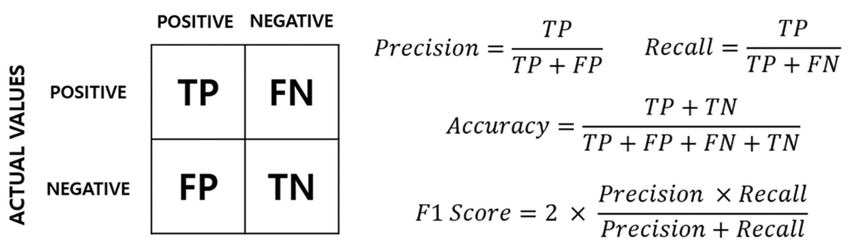

## Dataset

The dataset consists of gene expression of a set of genes and a label for which cell type they belong to. From the gene expression, we want to learn how to predict which cell type they belong to.

In [112]:
# Load the data
data = pd.read_csv('celltype_gene_expression_mixed.csv')
print('---- Data Before normaliztions ----')
print(data.shape)

label_to_cell = {0: 'Cell type A',
                1: 'Cell type B',
                2: 'Cell type C',
                3: 'Cell type D'}


print(data.head(), '\n')

# Function to normalize and standardize your data
def lognormdata(data):
    DATA = {}
    for col in data.columns:
        if col != 'Cell_Type':
            logs = np.log1p(data[col].values)
            standardized = (logs - np.mean(logs)) / np.std(logs)
            minmax = (standardized - np.min(standardized)) / (np.max(standardized) - np.min(standardized))
            DATA[col] = minmax
        else:
            DATA[col] = data[col].values
    return pd.DataFrame(DATA)

data = lognormdata(data)
print('---- Data After normaliztions ----')
data.head()

---- Data Before normaliztions ----
(5700, 11)
   Gene_1_expression  Gene_2_expression  Gene_3_expression  Gene_4_expression  \
0           1.143116           0.976582           1.768418           0.702281   
1           0.617340           1.260906           1.792748           0.000000   
2           0.440765           1.145196           0.758176           2.200685   
3           2.020370           2.144620           0.000000           2.973628   
4           1.252375           2.266119           1.882734           0.697934   

   Gene_5_expression  Gene_6_expression  Gene_7_expression  Gene_8_expression  \
0           2.407401           1.783843           0.803777           2.290556   
1           0.046053           0.610873           3.928312           0.712108   
2           0.636057           1.079948           1.304419           2.384071   
3           0.511100           0.464382           2.580525           1.498887   
4           0.000000           1.193303           2.467937   

,Gene_1_expression,Gene_2_expression,Gene_3_expression,Gene_4_expression,Gene_5_expression,Gene_6_expression,Gene_7_expression,Gene_8_expression,Gene_9_expression,Gene_10_expression,Cell_Type
0,0.314310,0.262588,0.372187,0.212473,0.471261,0.426511,0.184669,0.445432,0.469456,0.297317,Cell type A
1,0.198246,0.314382,0.375385,0.000000,0.017308,0.198617,0.499330,0.201099,0.608908,0.306845,Cell type A
2,0.150576,0.294136,0.206247,0.464657,0.189238,0.305081,0.261351,0.455912,0.668948,0.000000,Cell type A
3,0.455791,0.441531,0.000000,0.551055,0.158697,0.158899,0.399311,0.342509,0.000000,0.411848,Cell type A
4,0.334813,0.456140,0.386976,0.211451,0.000000,0.327188,0.389309,0.264057,0.461962,0.460657,Cell type A


## **Task 2:**

Split the data into training (80%) and test (20%) set. Note: most machine learning algorithms require numerical input labels rather than categorical string labels- therefore we assign intergers to the cell type classes.


In [ ]:
# ==========================================
# EXERCISE 1: Extract features matrix X (all gene expression columns)
# ==========================================
# hint: Save all columns except 'Cell_Type' under a variable 'X' which should be a matrix.

# =============== Insert your code here ===============

# =============== Finish your code here and do not change below ===============
try:
    assert isinstance(X, np.ndarray), f"X should be numpy array, got {type(X).__name__}"
    assert X.shape == (5700, 10), f"X shape should be (5700, 10), got {X.shape}"
    print('--- EXERCISE 1 ---')
    print('✓ All checks passed!')
    print('shape X:', X.shape)
except AssertionError as e:
    print(f'✗ Error: {e}')

In [115]:
# ==========================================
# EXERCISE 1: Extract features matrix X (all gene expression columns)
# ==========================================
# hint: Save all columns except 'Cell_Type' under a variable 'X' which should be a matrix.

# =============== Insert your code here ===============
X = data[[i for i in data.columns if i != 'Cell_Type']].to_numpy()

# =============== Finish your code here and do not change below ===============
try:
    assert isinstance(X, np.ndarray), f"X should be numpy array, got {type(X).__name__}"
    assert X.shape == (5700, 10), f"X shape should be (5700, 10), got {X.shape}"
    print('--- EXERCISE 1 ---')
    print('✓ All checks passed!')
    print('shape X:', X.shape)
except AssertionError as e:
    print(f'✗ Error: {e}')

--- EXERCISE 1 ---
✓ All checks passed!
shape X: (5700, 10)


In [113]:
# ==========================================
# EXERCISE 2: Create a vector that would store the labels of cell type column. Then, convert each label to a unique integer value.
# Name it label vector `y`
# ==========================================
# hint: use the following dictionary for mapping your labels to numbers:
cell_to_label = {'Cell type A': 0,
                'Cell type B': 1,
                'Cell type C': 2,
                'Cell type D': 3 }
# =============== Insert your code here ===============



# =============== Finish your code here and do not change below ===============
try:
    assert len(y) == 5700, f"Length should be 5700, got {len(y)}"
    assert set(y) == {0, 1, 2, 3}, f"Should contain labels {0,1,2,3}, got {set(y)}"
    assert all(isinstance(i, int) for i in y), "All labels should be integers"
    print('--- EXERCISE 2 ---')
    print('✓ All checks passed!')
except AssertionError as e:
    print(f'✗ Error: {e}')

--- EXERCISE 2 ---
✓ All checks passed!


In [116]:
# ==========================================
# EXERCISE 2: Create a vector that would store the labels of cell type column. Then, convert each label to a unique integer value.
# Name it label vector `y`
# ==========================================
# hint: use the following dictionary for mapping your labels to numbers:
cell_to_label = {'Cell type A': 0,
                'Cell type B': 1,
                'Cell type C': 2,
                'Cell type D': 3 }
# =============== Insert your code here ===============
y = data['Cell_Type'].tolist()
y = [cell_to_label[i] for i in y]
# =============== Finish your code here and do not change below ===============
try:
    assert len(y) == 5700, f"Length should be 5700, got {len(y)}"
    assert set(y) == {0, 1, 2, 3}, f"Should contain labels {0,1,2,3}, got {set(y)}"
    assert all(isinstance(i, int) for i in y), "All labels should be integers"
    print('--- EXERCISE 2 ---')
    print('✓ All checks passed!')
except AssertionError as e:
    print(f'✗ Error: {e}')

--- EXERCISE 2 ---
✓ All checks passed!


In [ ]:
# ==========================================
# EXERCISE 3: Split into train and test sets (80% train, 20% test). Make sure all your datasets are arrays.
# ==========================================
# hint: Set a random seed 42 for reproduciblity
from sklearn.model_selection import train_test_split
# =============== Insert your code here ===============


# =============== Finish your code here and do not change below ===============
try:
    assert all(isinstance(arr, np.ndarray) for arr in [X_train, X_test, y_train, y_test]), \
        "All variables should be numpy arrays"
    assert X_train.shape == (4560, 10), f"X_train shape should be (4560, 10), got {X_train.shape}"
    assert X_test.shape == (1140, 10), f"X_test shape should be (1140, 10), got {X_test.shape}"
    assert y_train.shape == (4560,), f"y_train shape should be (4560,), got {y_train.shape}"
    assert y_test.shape == (1140,), f"y_test shape should be (1140,), got {y_test.shape}"
    print('✓ All checks passed!')
    print(f'\nCorrect shapes:\nX_train: {X_train.shape}\nX_test: {X_test.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}')
except AssertionError as e:
    print(f'✗ Error: {e}')

In [117]:
# ==========================================
# EXERCISE 3: Split into train and test sets (80% train, 20% test). Make sure all your datasets are arrays.
# ==========================================
# hint: Set a random seed 42 for reproduciblity
from sklearn.model_selection import train_test_split
# =============== Insert your code here ===============
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)
y_train = np.array(y_train)
y_test = np.array(y_test)

# =============== Finish your code here and do not change below ===============
try:
    assert all(isinstance(arr, np.ndarray) for arr in [X_train, X_test, y_train, y_test]), \
        "All variables should be numpy arrays"
    assert X_train.shape == (4560, 10), f"X_train shape should be (4560, 10), got {X_train.shape}"
    assert X_test.shape == (1140, 10), f"X_test shape should be (1140, 10), got {X_test.shape}"
    assert y_train.shape == (4560,), f"y_train shape should be (4560,), got {y_train.shape}"
    assert y_test.shape == (1140,), f"y_test shape should be (1140,), got {y_test.shape}"
    print('✓ All checks passed!')
    print(f'\nCorrect shapes:\nX_train: {X_train.shape}\nX_test: {X_test.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}')
except AssertionError as e:
    print(f'✗ Error: {e}')

✓ All checks passed!

Correct shapes:
X_train: (4560, 10)
X_test: (1140, 10)
y_train: (4560,)
y_test: (1140,)


---
---
## **Task 3:** Use sklearn to fit a multiclass logistic regression model

## Now, familiarize yourself with the sklearn library. This is the section on logistic regression : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html



## You will find `sklearn.linear_model.LogisticRegression`, the sklearn implementation of logistic regression. Use this sklearn class to implement logistic regression. Obtain estimates of the weights on `X_train` and `y_train` and compute performance metrics such as accuracy and weighted F1-score on `X_test` and `y_test`.

## Calculate the ROC AUC and plot its curve for all classes.

## Additionally, calculate and plot Precision-Recall (PR) curves for each class, which is particularly useful for imbalanced datasets or multi-class classification.

## Steps to follow for evaluation of the model:

## - Train logistic regression on the standardized training data using `clf.fit(X_train, y_train)`.
## - Predict class labels and probabilities on the test data using `clf.predict(X_test)` and `clf.predict_proba(X_test)`.
## - Calculate accuracy and weighted F1 score with `accuracy_score` and `f1_score`.
## - Binarize the test labels using `label_binarize` for multi-class PR curve plotting (1)
## - Plot precision-recall curves for each class with `precision_recall_curve` and compute area under the curve (AUC) using `auc`.
## - Visualize PR curves with `matplotlib.pyplot`.

## This approach gives a comprehensive evaluation of logistic regression beyond simple accuracy metrics.


## In multi-class classification, each test sample belongs to one of several classes. However, some evaluation metrics, including precision-recall (PR) curves, require the labels to be in a binary indicator format for each class, rather than a single integer class label.The `label_binarize` function from `sklearn.preprocessing` converts the vector of integer class labels into a binary matrix, where each row corresponds to a test sample,and each column corresponds to a class.


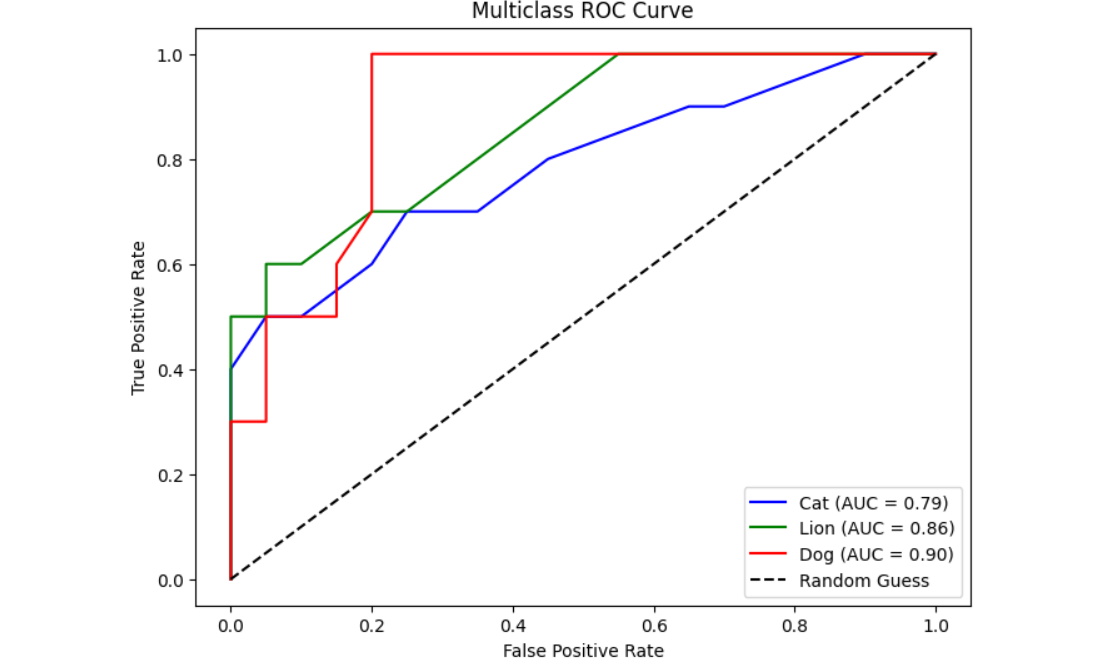

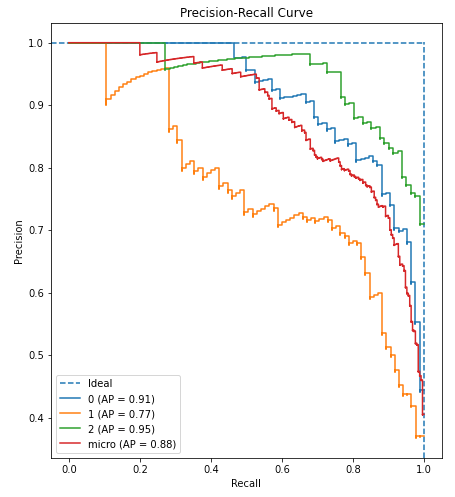

## We provided the visualization function for your convinience:


In [118]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix

def plot_multiclass_roc_pr(y_test_bin, y_prob, label_to_cell):
    """
    Plot ROC, Precision-Recall curves, and Confusion Matrix for multiclass classification.
    Automatically binarizes labels if not already one-hot encoded.

    Parameters
    ----------
    y_test_bin : np.ndarray
        True labels (either class indices or binary matrix).
    y_prob : np.ndarray
        Predicted probabilities, shape (n_samples, n_classes).
    label_to_cell : dict or list
        Mapping from class index to label name.
    """

    # --- Ensure labels are in binary (one-hot) form ---
    if y_test_bin.ndim == 1 or y_test_bin.shape[1] == 1:
        # Convert class indices to binary matrix
        n_classes = y_prob.shape[1]
        y_test_bin = label_binarize(y_test_bin, classes=np.arange(n_classes))
    else:
        n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(6, 10))

    # --- ROC Curve ---
    plt.subplot(3, 1, 1)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{label_to_cell[i]} (AUC={roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- Precision-Recall Curve ---
    plt.subplot(3, 1, 2)
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, lw=2, label=f'{label_to_cell[i]} (AUC={pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(fontsize=9)
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- Confusion Matrix ---
    y_true = np.argmax(y_test_bin, axis=1)
    y_pred = np.argmax(y_prob, axis=1)
    cm = confusion_matrix(y_true, y_pred)

    plt.subplot(3, 1, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[label_to_cell[i] for i in range(n_classes)],
                yticklabels=[label_to_cell[i] for i in range(n_classes)])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')

    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================
# EXERCISE 1: Define your logistic regression model and call it 'clf'
# ==========================================
# =============== Insert your code here ===============

# =============== Finish your code here and do not change below ===============
try:
    assert 'clf' in locals(), "Variable 'clf' is not defined"
    assert isinstance(clf, LogisticRegression), f"'clf' should be LogisticRegression, got {type(clf).__name__}"
    print('✓ Logistic Regression model defined correctly!')
except AssertionError as e:
    print(f'✗ Error: {e}')


In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==========================================
# EXERCISE 1: Define your logistic regression model and call it 'clf'
# ==========================================
# =============== Insert your code here ===============
clf = LogisticRegression(max_iter=1000, random_state=42)

# =============== Finish your code here and do not change below ===============
try:
    assert 'clf' in locals(), "Variable 'clf' is not defined"
    assert isinstance(clf, LogisticRegression), f"'clf' should be LogisticRegression, got {type(clf).__name__}"
    print('✓ Logistic Regression model defined correctly!')
except AssertionError as e:
    print(f'✗ Error: {e}')

✓ Logistic Regression model defined correctly!


In [ ]:
# ==========================================
# EXERCISE 2: Fit your model on `X_train`
# ==========================================
# =============== Insert your code here ===============


# =============== Finish your code here and do not change below ===============

In [120]:
# ==========================================
# EXERCISE 2: Fit your model on `X_train`
# ==========================================
# =============== Insert your code here ===============
clf.fit(X_train, y_train)

# =============== Finish your code here and do not change below ===============
try:
    assert hasattr(clf, 'coef_'), "Model has not been fitted yet. Use clf.fit()"
    assert clf.coef_.shape == (4, 10), f"Model fitted incorrectly. Expected coef_ shape (4, 10), got {clf.coef_.shape}"
    print('✓ Model fitted correctly!')
except AssertionError as e:
    print(f'✗ Error: {e}')

✓ Model fitted correctly!


In [ ]:
# ==========================================
# EXERCISE 3: After training, you need to predict on X_test. It will give you the probabilities (y_prob).
# Convert your probabilities to the most likely target label with argmax (y_pred). Then binarize them with label_binarize (y_pred_bin)
# -- Required Variables -- :
# y_prob --> probabilities (test_samples, 4), e.g [[0.1, 0.2, 0.6, 0.1], ...] -> third index has the highest prob
# y_pred --> predictions (test_samples,), e.g [2, ...] -> third index is saved as it had the highest prob
# y_pred_bin --> binarized (test_samples, 4), e.g [[0, 0, 1, 0], ...] -> Only the index with the highest prob is one, rest are zero.
# ==========================================
# hint: You can use clf.predict_proba to get the probabilities
# =============== Insert your code here ===============




# =============== Finish your code here and do not change below ===============
try:
    assert 'y_prob' in locals(), "Variable 'y_prob' is not defined"
    assert 'y_pred' in locals(), "Variable 'y_pred' is not defined"
    assert 'y_pred_bin' in locals(), "Variable 'y_pred_bin' is not defined"
    assert y_prob.shape == (1140, 4), f"y_prob shape should be (1140, 4), got {y_prob.shape}"
    assert y_pred.shape == (1140,), f"y_pred shape should be (1140,), got {y_pred.shape}"
    assert y_pred_bin.shape == (1140, 4), f"y_pred_bin shape should be (1140, 4), got {y_pred_bin.shape}"
    assert set(y_pred).issubset({0, 1, 2, 3}), f"y_pred should contain labels 0-3, got {set(y_pred)}"
    assert set(y_pred_bin.flatten()).issubset({0, 1}), "y_pred_bin should only contain 0s and 1s"
    print('✓ All predictions made correctly!')
    print(f'\nShapes:\ny_prob: {y_prob.shape}\ny_pred: {y_pred.shape}\ny_pred_bin: {y_pred_bin.shape}')
except AssertionError as e:
    print(f'✗ Error: {e}')

In [121]:
# ==========================================
# EXERCISE 3: After training, you need to predict on X_test. It will give you the probabilities (y_prob).
# Convert your probabilities to the most likely target label with argmax (y_pred).
# -- Required Variables -- :
# y_prob --> probabilities (test_samples, 4), e.g [[0.1, 0.2, 0.6, 0.1], ...] -> third index has the highest prob
# y_pred --> predictions (test_samples,), e.g [2, ...] -> third index is saved as it had the highest prob
# ==========================================
# hint: You can use clf.predict_proba to get the probabilities
# =============== Insert your code here ===============
# y_test
y_prob = clf.predict_proba(X_test)
y_pred = np.argmax(y_prob, axis=1)

# =============== Finish your code here and do not change below ===============
try:
    assert 'y_prob' in locals(), "Variable 'y_prob' is not defined"
    assert 'y_pred' in locals(), "Variable 'y_pred' is not defined"
    assert y_prob.shape == (1140, 4), f"y_prob shape should be (1140, 4), got {y_prob.shape}"
    assert y_pred.shape == (1140,), f"y_pred shape should be (1140,), got {y_pred.shape}"
    assert set(y_pred).issubset({0, 1, 2, 3}), f"y_pred should contain labels 0-3, got {set(y_pred)}"
    print('✓ All predictions made correctly!')
    print(f'\nShapes:\ny_prob: {y_prob.shape}\ny_pred: {y_pred.shape}\ny_pred_bin: {y_pred_bin.shape}')
except AssertionError as e:
    print(f'✗ Error: {e}')

✓ All predictions made correctly!

Shapes:
y_prob: (1140, 4)
y_pred: (1140,)
y_pred_bin: (1140, 4)


## Now, let's see the performance of your model on test set.

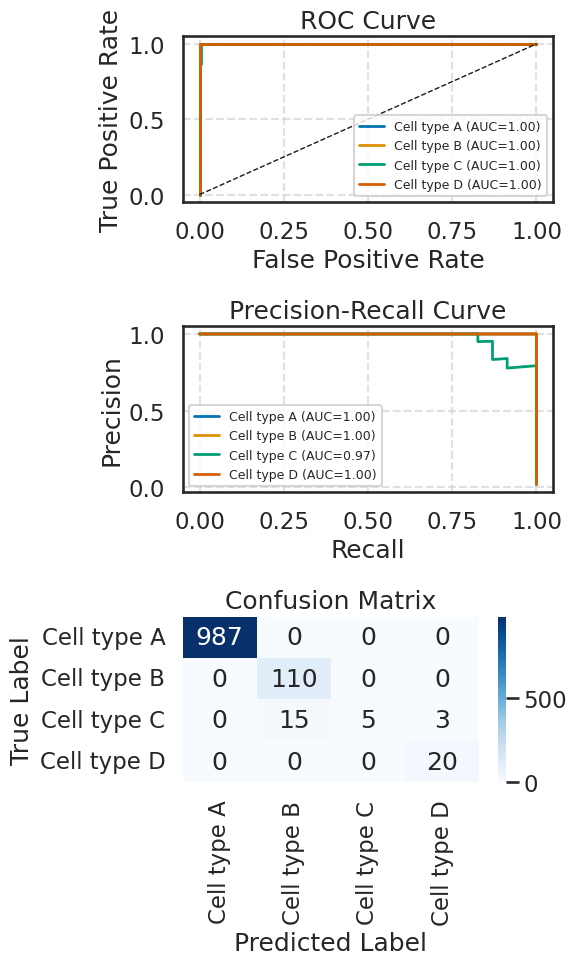

Accuracy Test: 0.9842
F1-Score Test: 0.9796
Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       987
     Class 1       0.88      1.00      0.94       110
     Class 2       1.00      0.22      0.36        23
     Class 3       0.87      1.00      0.93        20

    accuracy                           0.98      1140
   macro avg       0.94      0.80      0.81      1140
weighted avg       0.99      0.98      0.98      1140



In [122]:
# Calculate and report your accuracy and f1-score on test set
# Do not change
acc_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred, average='weighted')
plot_multiclass_roc_pr(y_test, y_prob, label_to_cell)
print(f"Accuracy Test: {acc_test:.4f}", )
print(f"F1-Score Test: {f1_test:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3']))


## What do you observe? How is your model performing?
## Do you think model is performing perfectly for all classes?
## Hint- think of how an unbalanced dataset can affect these scores?
## Is your model performing well for ALL the classes? If not, why?

## **Task 4:**

## To find out if this dataset is imbalanced we would need to check how many samples are present in each cell type and visualise the distributions of each cell types by plotting a per-cell type histogram of each cell type in the same plot.

## we have provided you with the code to do this below.

## When you run the code, what do you see? Are there equal number of each cell types samples? Are the distributions of the cell types very different from each other, or do they overlap?

In [123]:
# Calculate sample size per cell type
celltype_size = data['Cell_Type'].value_counts()
print("Sample size per Cell_Type:")
print(celltype_size)

Sample size per Cell_Type:
Cell_Type
Cell type A    5000
Cell type B     500
Cell type C     100
Cell type D     100
Name: count, dtype: int64


To mitigate the class inbalance, we can apply something known as class weighting, assigning higher weights to smaller classes so that the model gives them proportional influence during training.

## Weighted Multiclass Cross-Entropy Loss

When some classes appear more often than others, the model might become biased toward the majority classes.  
To handle this imbalance, we can assign a **class weight** \( w_j \) to each class \( j \), giving more importance to underrepresented classes.

The **weighted loss function** becomes:

$$
L(w) = - \sum_{i=1}^m \sum_{j=1}^K w_j \, y_{ij} \log P(y_i = j \mid \mathbf{x_i})
$$
Where:
- $m$: number of samples  
- $K$: number of classes  
- $y_{ij}$: indicator (1 if sample $i$ belongs to class $j$, otherwise 0  
- $P(y_i = j \mid \mathbf{x_i})$: predicted probability that sample \( i \) belongs to class \( j \)  
- $w_j$: **class weight** — a scaling factor that increases or decreases the loss contribution of class $j$

In [ ]:

# ==========================================
# EXERCISE 1: Chenges the weights below and observe the performance changes. Find the best weights that optimizes your model's performance.
# ==========================================
# =============== Insert your code here ===============
weights = {
    cell_to_label["Cell type A"]:1, # insert your class weight
    cell_to_label["Cell type B"]:1, # insert your class weight
    cell_to_label["Cell type C"]:1, # insert your class weight
    cell_to_label["Cell type D"]:1, # insert your class weight
}
# =============== Finish your code here and do not change below ===============
clf = LogisticRegression(max_iter=1000, class_weight=weights)
clf.fit(X_train, y_train)
y_prob = clf.predict_proba(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_test_bin = label_binarize(y_test, classes=list(cell_to_label.values()))
# eval
acc_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred, average='weighted')
plot_multiclass_roc_pr(y_test, y_prob, label_to_cell)
print(f"Accuracy Test: {acc_test:.4f}", )
print(f"F1-Score Test: {f1_test:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3']))

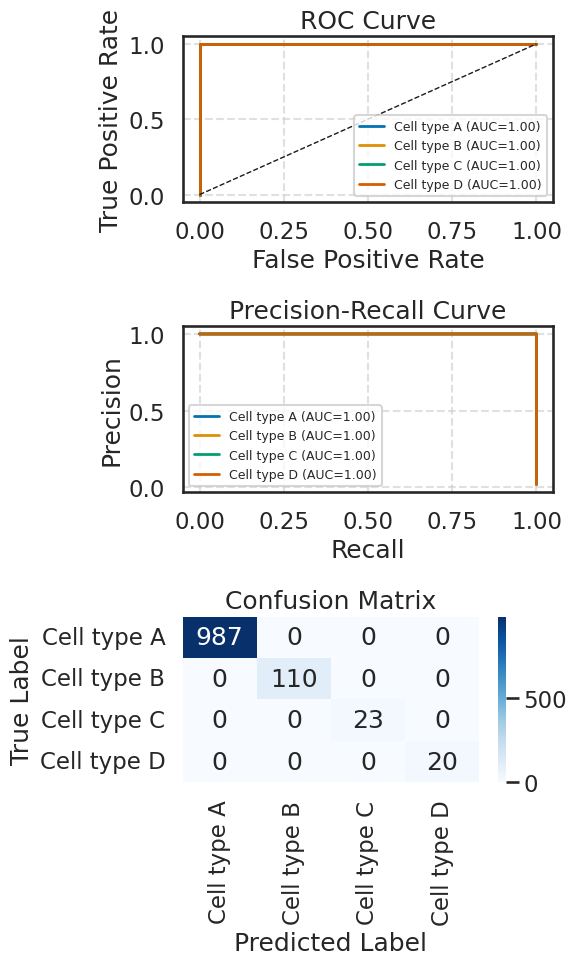

Accuracy Test: 1.0000
F1-Score Test: 1.0000
Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       987
     Class 1       1.00      1.00      1.00       110
     Class 2       1.00      1.00      1.00        23
     Class 3       1.00      1.00      1.00        20

    accuracy                           1.00      1140
   macro avg       1.00      1.00      1.00      1140
weighted avg       1.00      1.00      1.00      1140



In [124]:

# ==========================================
# EXERCISE 1: Chenges the weights below and observe the performance changes. Find the best weights that optimizes your model's performance.
# ==========================================
# =============== Insert your code here ===============
weights = {
    cell_to_label["Cell type A"]:1, # insert your class weight
    cell_to_label["Cell type B"]: 9, # insert your class weight
    cell_to_label["Cell type C"]: 18, # insert your class weight
    cell_to_label["Cell type D"]: 18, # insert your class weight
}
# =============== Finish your code here and do not change below ===============
clf = LogisticRegression(max_iter=1000, class_weight=weights)
clf.fit(X_train, y_train)
y_prob = clf.predict_proba(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_test_bin = label_binarize(y_test, classes=list(cell_to_label.values()))
# eval
acc_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred, average='weighted')
plot_multiclass_roc_pr(y_test, y_prob, label_to_cell)
print(f"Accuracy Test: {acc_test:.4f}", )
print(f"F1-Score Test: {f1_test:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3']))